In [16]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn

# Check PyTorch version
torch.__version__

'2.12.0+cu130'

In [17]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [18]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [19]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None, title=''):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    plt.title(title)
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14})

### 1. linear-regression-data1.csv

In [20]:
import pandas as pd

df = pd.read_csv(r'linear-regression-data1.csv')
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [21]:
# Convert to tensors
X1 = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y1 = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X1.shape, y1.shape)


torch.Size([50, 1]) torch.Size([50, 1])


In [30]:
# Convert to tensors
X1 = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y1 = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X1.shape, y1.shape)

# Split data
split1 = int(0.8 * len(X1))
X1_train, y1_train = X1[:split1], y1[:split1]
X1_test,  y1_test  = X1[split1:], y1[split1:]
len(X1_train), len(X1_test)

torch.Size([50, 1]) torch.Size([50, 1])


(40, 10)

In [31]:
def plot_predictions(train_data= X1_train, 
                     train_labels= y1_train, 
                     test_data=X1_test, 
                     test_labels=y1_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

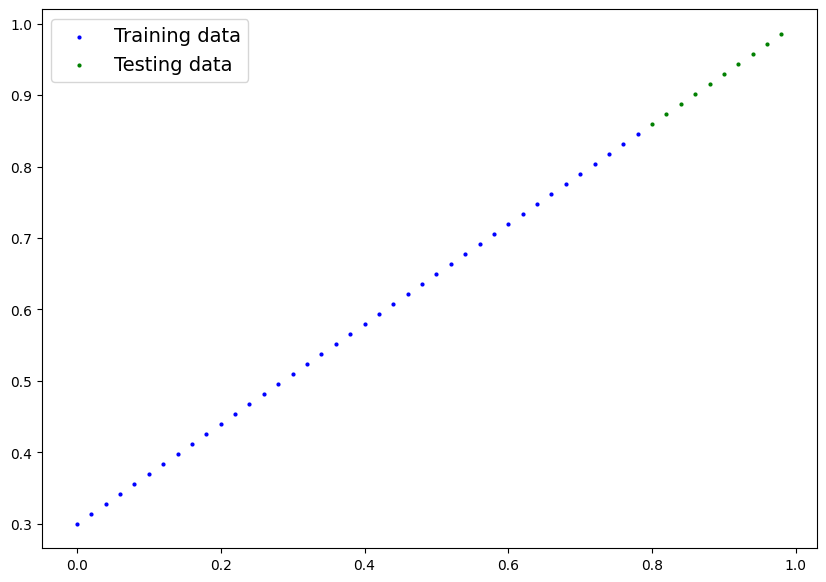

In [35]:
plot_predictions(X1_train, y1_train, X1_test, y1_test)

In [36]:
# Instantiate model, loss, optimizer
torch.manual_seed(42)
model1 = LinearRegressionNN()
loss_fn1 = nn.L1Loss()
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.01)

# Brief training run (10 epochs) to check whether the model can learn
for epoch in range(10):
    model1.train()
    pred = model1(X1_train)
    loss = loss_fn1(pred, y1_train)
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()

    model1.eval()
    with torch.inference_mode():
        test_loss = loss_fn1(model1(X1_test), y1_test)
    print(f'Epoch {epoch} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}')

Epoch 0 | Train loss: 0.5552 | Test loss: 0.5740
Epoch 1 | Train loss: 0.5437 | Test loss: 0.5605
Epoch 2 | Train loss: 0.5321 | Test loss: 0.5470
Epoch 3 | Train loss: 0.5206 | Test loss: 0.5336
Epoch 4 | Train loss: 0.5091 | Test loss: 0.5201
Epoch 5 | Train loss: 0.4976 | Test loss: 0.5066
Epoch 6 | Train loss: 0.4861 | Test loss: 0.4932
Epoch 7 | Train loss: 0.4745 | Test loss: 0.4797
Epoch 8 | Train loss: 0.4630 | Test loss: 0.4662
Epoch 9 | Train loss: 0.4515 | Test loss: 0.4527


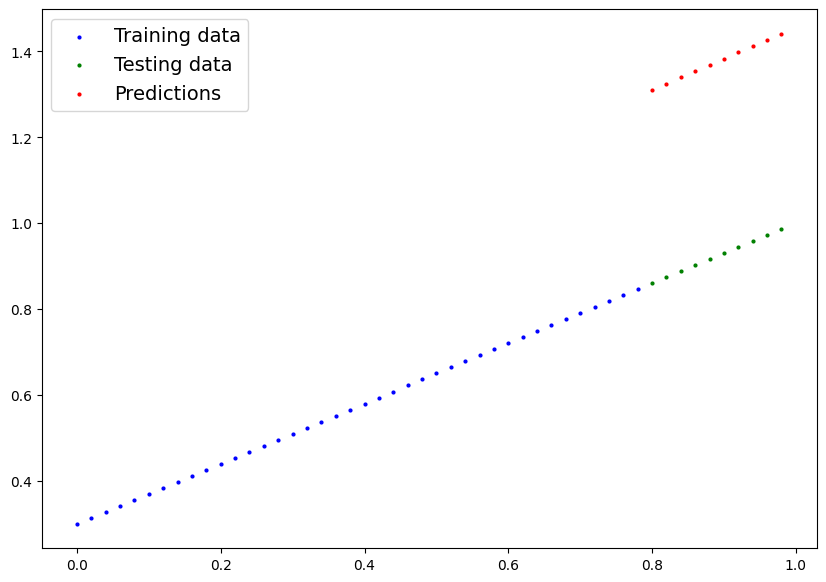

In [39]:
# Visualise predictions after brief training
model1.eval()
with torch.inference_mode():
    preds1 = model1(X1_test)
plot_predictions(X1_train, y1_train, X1_test, y1_test, preds1)



### 2. assignment-data.csv

In [40]:
df2 = pd.read_csv(r'assignment-data.csv')
df2.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [41]:
X2 = torch.tensor(df2['x'].values, dtype=torch.float32).unsqueeze(1)
y2 = torch.tensor(df2['y'].values, dtype=torch.float32).unsqueeze(1)
print(X2.shape, y2.shape)

split2 = int(0.8 * len(X2))
X2_train, y2_train = X2[:split2], y2[:split2]
X2_test,  y2_test  = X2[split2:], y2[split2:]
len(X2_train), len(X2_test)

torch.Size([50, 1]) torch.Size([50, 1])


(40, 10)

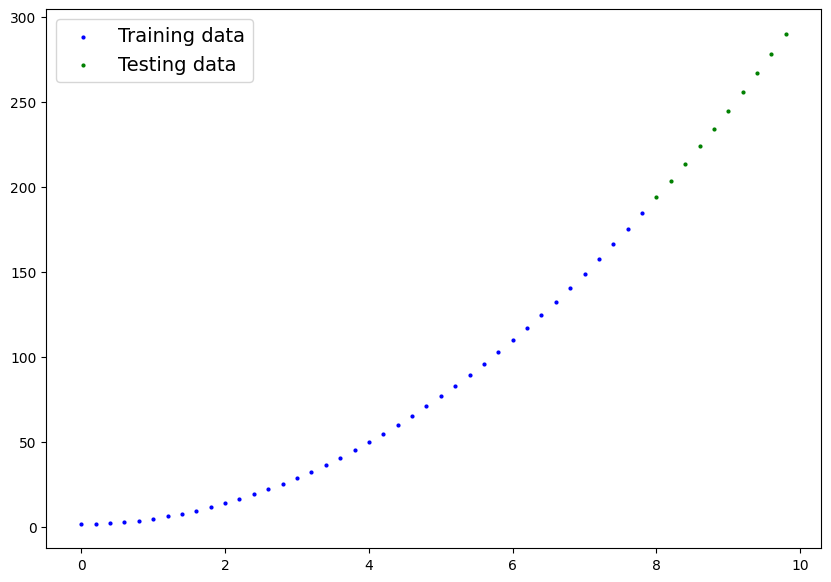

In [43]:
plot_predictions(X2_train, y2_train, X2_test, y2_test)

In [44]:
torch.manual_seed(42)
model2 = LinearRegressionNN()
loss_fn2 = nn.L1Loss()
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.01)

for epoch in range(10):
    model2.train()
    pred = model2(X2_train)
    loss = loss_fn2(pred, y2_train)
    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()

    model2.eval()
    with torch.inference_mode():
        test_loss = loss_fn2(model2(X2_test), y2_test)
    print(f'Epoch {epoch} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}')

Epoch 0 | Train loss: 59.8083 | Test loss: 232.6285
Epoch 1 | Train loss: 59.6462 | Test loss: 232.2714
Epoch 2 | Train loss: 59.4841 | Test loss: 231.9143
Epoch 3 | Train loss: 59.3220 | Test loss: 231.5572
Epoch 4 | Train loss: 59.1599 | Test loss: 231.2001
Epoch 5 | Train loss: 58.9978 | Test loss: 230.8430
Epoch 6 | Train loss: 58.8357 | Test loss: 230.4859
Epoch 7 | Train loss: 58.6736 | Test loss: 230.1288
Epoch 8 | Train loss: 58.5115 | Test loss: 229.7717
Epoch 9 | Train loss: 58.3494 | Test loss: 229.4146


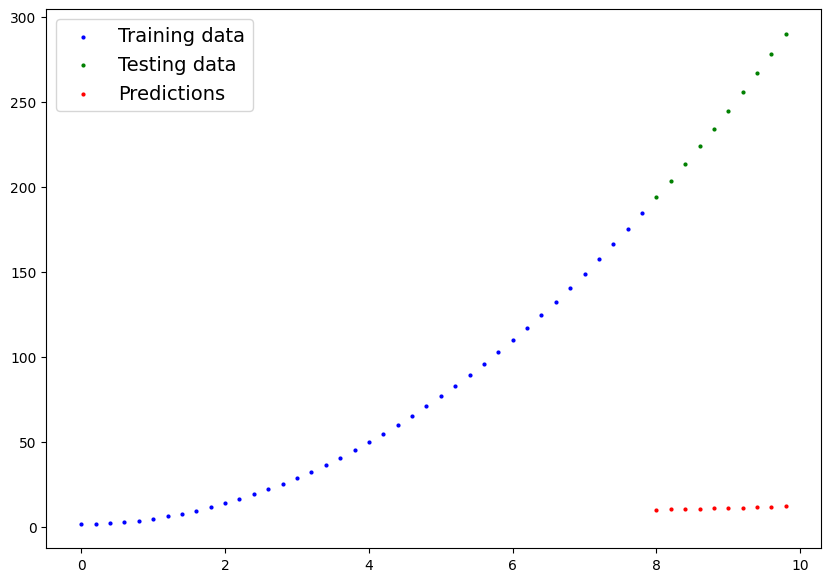

In [45]:
model2.eval()
with torch.inference_mode():
    preds2 = model2(X2_test)
plot_predictions(X2_train, y2_train, X2_test, y2_test, preds2)

### 3. assignment-data2.csv

In [46]:
df3 = pd.read_csv(r'assignment-data2.csv')
df3.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [47]:
X3 = torch.tensor(df3['x'].values, dtype=torch.float32).unsqueeze(1)
y3 = torch.tensor(df3['y'].values, dtype=torch.float32).unsqueeze(1)
print(X3.shape, y3.shape)

split3 = int(0.8 * len(X3))
X3_train, y3_train = X3[:split3], y3[:split3]
X3_test,  y3_test  = X3[split3:], y3[split3:]
len(X3_train), len(X3_test)

torch.Size([99, 1]) torch.Size([99, 1])


(79, 20)

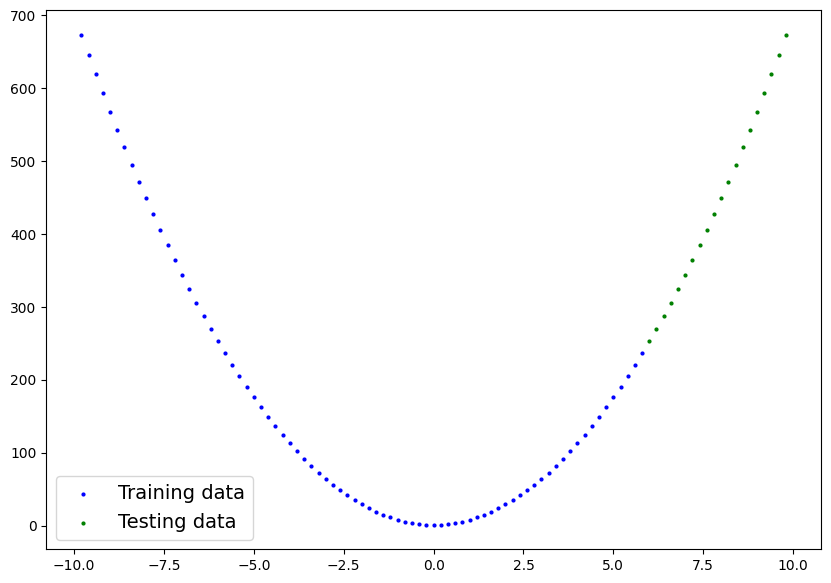

In [48]:
plot_predictions(X3_train, y3_train, X3_test, y3_test)

In [49]:
torch.manual_seed(42)
model3 = LinearRegressionNN()
loss_fn3 = nn.L1Loss()
optimizer3 = torch.optim.SGD(model3.parameters(), lr=0.01)

for epoch in range(10):
    model3.train()
    pred = model3(X3_train)
    loss = loss_fn3(pred, y3_train)
    optimizer3.zero_grad()
    loss.backward()
    optimizer3.step()

    model3.eval()
    with torch.inference_mode():
        test_loss = loss_fn3(model3(X3_test), y3_test)
    print(f'Epoch {epoch} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}')

Epoch 0 | Train loss: 175.2991 | Test loss: 440.4581
Epoch 1 | Train loss: 175.2491 | Test loss: 440.6061
Epoch 2 | Train loss: 175.1991 | Test loss: 440.7542
Epoch 3 | Train loss: 175.1491 | Test loss: 440.9022
Epoch 4 | Train loss: 175.0991 | Test loss: 441.0501
Epoch 5 | Train loss: 175.0491 | Test loss: 441.1981
Epoch 6 | Train loss: 174.9991 | Test loss: 441.3461
Epoch 7 | Train loss: 174.9491 | Test loss: 441.4941
Epoch 8 | Train loss: 174.8991 | Test loss: 441.6422
Epoch 9 | Train loss: 174.8491 | Test loss: 441.7901


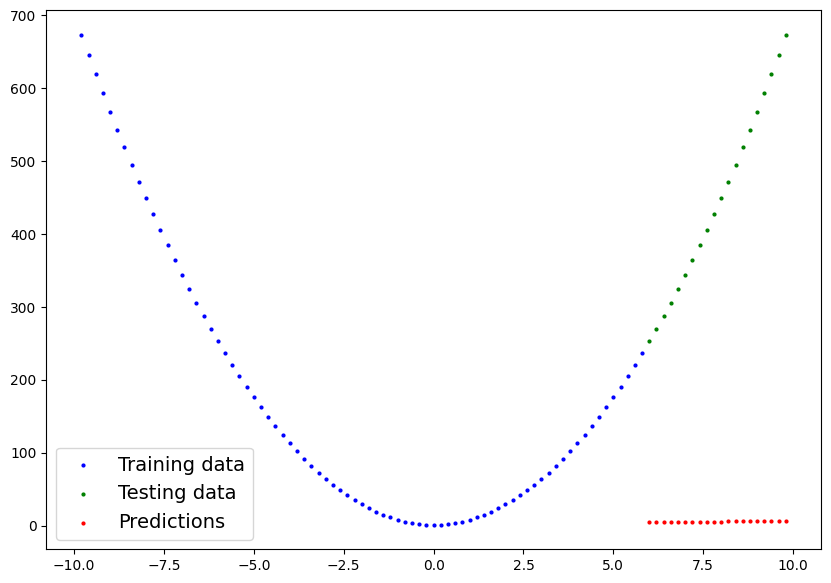

In [51]:
model3.eval()
with torch.inference_mode():
    preds3 = model3(X3_test)
plot_predictions(X3_train, y3_train, X3_test, y3_test, preds3)


## Conclusion

The LinearRegressionNN is only appropriate for datasets that follow a linear relationship between x and y.<br>
<br>
<b>linear-regression-data1.csv</b> → The model learns successfully. The data is linear, which matches the model's architecture exactly, and the loss decreases steadily during training.<br>
<b>assignment-data.csv</b> → The model can be trained, but the loss does not converge well, suggesting the underlying relationship is not linear. The model is insufficient for this dataset.<br>
<b>assignment-data2.csv</b> → Same situation as above. The model trains without errors, but the loss behavior indicates the data is non-linear and cannot be properly captured by a single linear layer.